# Anomalock — Exploratory Data Analysis

Source: RBA Dataset (Wiefling et al.), Zenodo record 6782156 — "Login Data Set for Risk-Based Authentication".
Full dataset: 33M+ login events, 3.3M+ users, Feb 2020–Feb 2021, large-scale SSO service in Norway.

This notebook works on a **subsample** (`data/processed/rba_sample.parquet`, ~300K rows / ~74K users) produced by
`src/anomalock/ingest/subsample.py`. The subsample keeps every row for a) all users with a confirmed
`Is Account Takeover` event, and b) a random selection of additional whole users, until the row budget is hit.
Sampling whole users (not individual rows) preserves each user's full login history, which later feature
engineering (login velocity, time-of-day deviation, device/IP novelty) depends on.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)

df = pd.read_parquet('../data/processed/rba_sample.parquet')
df['Login Timestamp'] = pd.to_datetime(df['Login Timestamp'])
df.shape

(300003, 16)

In [2]:
df.head()

,index,Login Timestamp,User ID,Round-Trip Time [ms],IP Address,Country,Region,City,ASN,User Agent String,Browser Name and Version,OS Name and Version,Device Type,Login Successful,Is Attack IP,Is Account Takeover
0,5777119,2020-04-22 12:11:20.386,-9223369089733265380,NaN,23.137.224.9,US,-,-,393398,Mozilla/5.0 (iPhone; CPU iPhone OS 11_2_6 lik...,Chrome Mobile 80.0.3987,iOS 11.2.6,mobile,False,False,False
1,9685347,2020-06-17 09:10:16.605,-9223159049542774599,NaN,66.248.237.94,US,-,-,393398,Mozilla/5.0 (iPhone; CPU iPhone OS 13_4 like ...,Chrome Mobile 81.0.4044.1925,iOS 13.4,mobile,False,True,False
2,17279618,2020-09-30 18:50:09.531,-9223159049542774599,NaN,209.236.123.164,US,-,-,393398,Mozilla/5.0 (iPhone; CPU iPhone OS 13_4 like ...,Chrome Mobile 81.0.4044.1930,iOS 13.4,mobile,False,True,False
3,4877536,2020-04-09 17:53:31.527,-9223064613846767867,NaN,83.243.249.220,NO,Møre og Romsdal,Ålesund,41164,Mozilla/5.0 (X11; CrOS x86_64 13020.55.1) App...,Chrome 64.0.3282,Chrome OS 13020.55.1,desktop,False,False,False
4,4885722,2020-04-09 20:30:37.995,-9223064613846767867,NaN,83.243.249.220,NO,Møre og Romsdal,Ålesund,41164,Mozilla/5.0 (X11; CrOS x86_64 13020.55.1) App...,Chrome 64.0.3282,Chrome OS 13020.55.1,desktop,True,False,False


## Schema, dtypes, missingness

In [3]:
df.dtypes

index                                int64
Login Timestamp             datetime64[us]
User ID                              int64
Round-Trip Time [ms]               float64
IP Address                             str
Country                                str
Region                                 str
City                                   str
ASN                                  int64
User Agent String                      str
Browser Name and Version               str
OS Name and Version                    str
Device Type                            str
Login Successful                      bool
Is Attack IP                          bool
Is Account Takeover                   bool
dtype: object

In [4]:
# Round-Trip Time is mostly missing (~94%) — the RBA paper notes it is only captured
# for a subset of client/server configurations, not systematically absent for attacks.
# Region/City/Device Type have negligible missingness.
df.isna().mean().sort_values(ascending=False).to_frame('missing_frac')

,missing_frac
Round-Trip Time [ms],0.936841
Region,0.000307
City,0.000183
Device Type,0.000010
index,0.000000
Login Timestamp,0.000000
User ID,0.000000
IP Address,0.000000
Country,0.000000
ASN,0.000000


## Label distribution

Two attack-related signals exist in this dataset and they are **not the same thing**:
- `Is Attack IP`: a noisy IP-reputation heuristic (the source IP appears on a threat-intel blocklist at login time). Common — doesn't mean the login succeeded or the account was compromised.
- `Is Account Takeover`: rare, higher-confidence ground truth — the dataset authors' label for confirmed account takeover attempts. This is the target we care about for supervised modeling.

In [5]:
print('Is Attack IP rate:      {:.4%}'.format(df['Is Attack IP'].mean()))
print('Is Account Takeover rate: {:.5%}'.format(df['Is Account Takeover'].mean()))
print('Overlap (both True):', int((df['Is Attack IP'] & df['Is Account Takeover']).sum()), '/', int(df['Is Account Takeover'].sum()))
print('Login Successful rate:', df['Login Successful'].mean())

Is Attack IP rate:      8.4399%
Is Account Takeover rate: 0.04700%
Overlap (both True): 77 / 141
Login Successful rate: 0.7330026699733002


This confirms `Is Account Takeover` is an extreme minority class (well under 0.1%). This has a direct
consequence for Phase 2 modeling: a supervised Random Forest trained on this label will have very little
positive signal, so an unsupervised approach (Isolation Forest) that doesn't depend on labeled attacks is
arguably the more realistic production analogue — real systems rarely have exhaustively labeled ATO events either.

## Per-user event counts

Behavioral features need enough history per user to be meaningful. How many logins does a typical user have in the sample?

In [6]:
counts = df.groupby('User ID').size()
counts.describe()

count    74353.000000
mean         4.034847
std          9.935294
min          1.000000
25%          1.000000
50%          2.000000
75%          4.000000
max        827.000000
dtype: float64

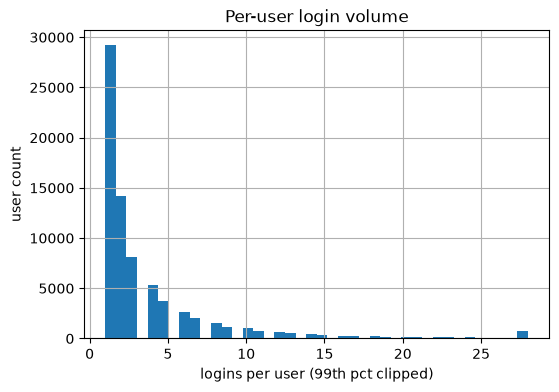

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
counts.clip(upper=counts.quantile(0.99)).hist(bins=40, ax=ax)
ax.set_xlabel('logins per user (99th pct clipped)')
ax.set_ylabel('user count')
ax.set_title('Per-user login volume')
plt.show()

## Temporal patterns

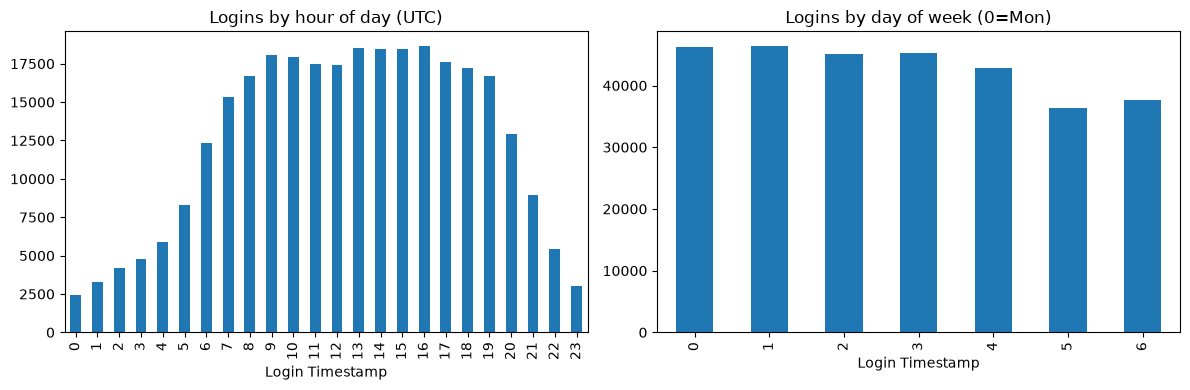

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['Login Timestamp'].dt.hour.value_counts().sort_index().plot(kind='bar', ax=axes[0])
axes[0].set_title('Logins by hour of day (UTC)')
df['Login Timestamp'].dt.dayofweek.value_counts().sort_index().plot(kind='bar', ax=axes[1])
axes[1].set_title('Logins by day of week (0=Mon)')
plt.tight_layout()
plt.show()

## Geography, device, and novelty signals

In [9]:
df['Country'].value_counts().head(15)

Country
NO    186633
US     70369
BR      8611
PL      7839
GB      4823
UA      3479
AU      3043
IN      2603
DE      2440
ID      1548
FR      1516
CZ      1125
RO       796
NL       549
IR       485
Name: count, dtype: int64

In [10]:
df['Device Type'].value_counts()

Device Type
mobile     202152
desktop     87646
tablet      10040
unknown       162
Name: count, dtype: int64

In [11]:
# Country diversity per user — most users log in from a single country;
# users with several countries are candidates for impossible-travel / account-sharing signals.
country_diversity = df.groupby('User ID')['Country'].nunique()
country_diversity.value_counts().sort_index().head(10)

Country
1     72880
2      1331
3       104
4        22
5         8
6         3
7         1
9         1
10        1
12        2
Name: count, dtype: int64

## Failed login patterns (brute-force signal)

In [12]:
fail_rate_by_user = df.groupby('User ID')['Login Successful'].apply(lambda s: 1 - s.mean())
fail_rate_by_user.describe()

count    74353.000000
mean         0.360715
std          0.406011
min          0.000000
25%          0.000000
50%          0.200000
75%          0.727273
max          1.000000
Name: Login Successful, dtype: float64

In [13]:
# Compare failure rate for ATO users vs. non-ATO users.
ato_users = set(df.loc[df['Is Account Takeover'], 'User ID'])
print('Median failure rate, ATO users:    ', fail_rate_by_user[fail_rate_by_user.index.isin(ato_users)].median())
print('Median failure rate, non-ATO users:', fail_rate_by_user[~fail_rate_by_user.index.isin(ato_users)].median())

Median failure rate, ATO users:     0.012408640726675968
Median failure rate, non-ATO users: 0.19999999999999996


## Takeaways for Phase 2 feature engineering

- `Is Account Takeover` is the ground-truth label but is extremely sparse (~0.05% of rows, 141 of 300K) —
  baseline rules and Isolation Forest (unsupervised) are essential complements to a supervised Random Forest,
  not just alternatives, given how little positive signal there is to train/validate on.
- `Is Attack IP` is a much noisier, higher-prevalence signal (~8.4% of rows) and will be treated as an input
  feature / weak signal, never as ground truth.
- **Counterintuitive finding:** ATO-linked users have a *lower* median per-user failure rate (1.2%) than
  non-ATO users (20%) — the opposite of a naive "brute force = more failures" assumption. This is consistent
  with the dataset's premise: these are credential-stuffing attacks using already-valid stolen passwords, not
  guessing attacks, so most attacker logins succeed on the first try. This means a failed-attempt-rate feature
  alone will likely be a weak or even inversely-correlated signal for this attack type — impossible-travel,
  device/IP/ASN novelty, and time-of-day deviation are likely to matter more here. Still worth engineering the
  failed-attempt-rate feature since it's the standard signal for the slow/low brute-force case described in the
  problem statement, even though it isn't the dominant signal for the account-takeover-labeled rows.
- Users vary widely in login volume (median 2, max 827); features needing rolling history should degrade
  gracefully for low-history users (e.g., a neutral/default score for a user's first few logins).
- Country/device diversity per user is directly usable for novelty and impossible-travel features.
